<a href="https://colab.research.google.com/github/Kubojah-Dan/kuboja-codeboosters-2026/blob/main/DAY4/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##PySpark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder\
        .appName("Day4_Big_Data_Sales")\
        .config('sql.adaptive.enabld','true')\
        .getOrCreate()
print("Spark version : ",spark.version)
print("SparkSession : ACTIVE")
print("Application : ",spark.sparkContext.appName)

Spark version :  4.0.2
SparkSession : ACTIVE
Application :  Day4_Big_Data_Sales


In [2]:
df_bronze = spark.read\
            .option('header','true')\
            .option('inferSchema','true')\
            .csv("large_sales_data.csv")
print("=== DATA SETS LOADED SUCESSFULLY ====")

=== DATA SETS LOADED SUCESSFULLY ====


In [3]:
print("=== Printing First 5 Rows ===")
df_bronze.show(5,truncate=False)

=== Printing First 5 Rows ===
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat   

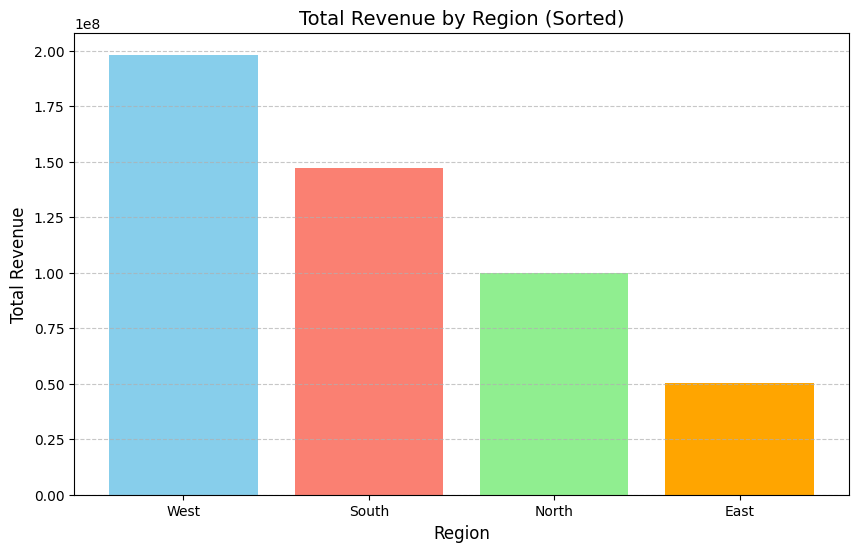

In [5]:
#=======================================================
# Total Revenue by Region
#=======================================================

region_revenue = df_bronze.groupBy("region") \
    .agg(F.sum("revenue").alias("total_revenue")) \
    .orderBy(F.col("total_revenue").desc()) \
    .toPandas()

plt.figure(figsize=(10, 6))
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'orchid']
plt.bar(region_revenue['region'], region_revenue['total_revenue'], color=colors[:len(region_revenue)])

plt.title('Total Revenue by Region (Sorted)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

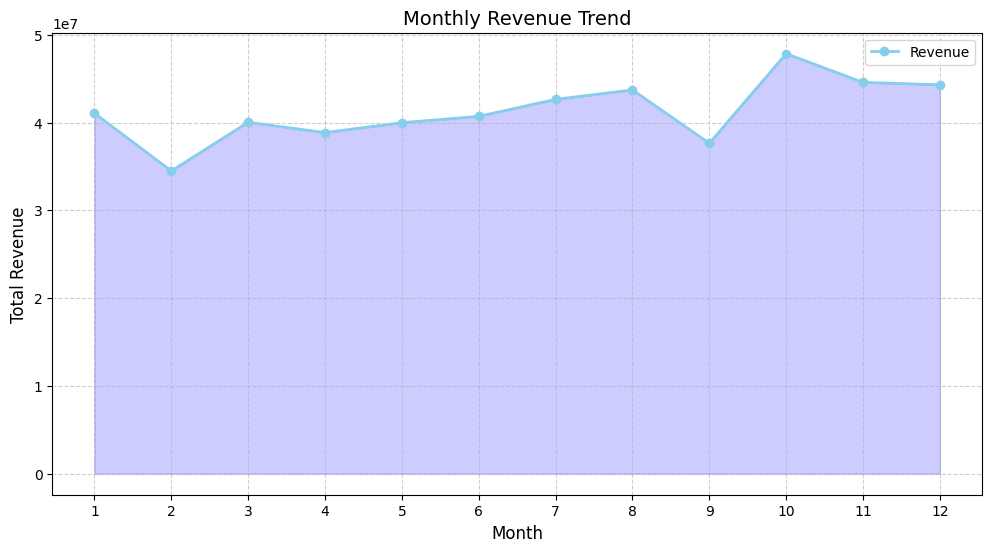

In [7]:
#====================================
# Monthly Revenue Trend
#====================================

monthly_revenue = df_bronze.withColumn("month_num", F.month("order_date")) \
    .groupBy("month_num") \
    .agg(F.sum("revenue").alias("total_revenue")) \
    .orderBy("month_num") \
    .toPandas()

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['month_num'], monthly_revenue['total_revenue'], color='skyblue', marker='o', linewidth=2, label='Revenue')

plt.fill_between(monthly_revenue['month_num'], monthly_revenue['total_revenue'], color='blue', alpha=0.2)

plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()